In [ ]:
import os
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array, array_to_img
from tqdm import tqdm
import tensorflow as tf
from PIL import Image

# Configurations
INPUT_DIR = r"C:\Users\BME\Desktop\skin dataset\train"
OUTPUT_DIR = r"C:\Users\Desktop\augmented_train(skin)"
IMG_SIZE = (224, 224)
AUG_PER_IMAGE = 10  # Number of augmentations per image

# Verify environment
print("TensorFlow version:", tf.__version__)
print("Input directory exists:", os.path.exists(INPUT_DIR))

# Create output directory
if not os.path.exists(OUTPUT_DIR):
    try:
        os.makedirs(OUTPUT_DIR)
        print("Output directory created successfully.")
    except PermissionError:
        print("Permission denied. Please run as administrator or choose a different directory.")
        exit()
else:
    print("Output directory already exists, using it.")

# Test augmentation to verify setup
print("Performing test augmentation...")
test_output_path = None
try:
    sample_files = [f for f in os.listdir(INPUT_DIR) if os.path.isdir(os.path.join(INPUT_DIR, f))]
    if sample_files:
        sample_class = sample_files[0]
        sample_img_name = next((f for f in os.listdir(os.path.join(INPUT_DIR, sample_class)) if f.lower().endswith(('.jpg', '.jpeg', '.png'))), None)
        if sample_img_name:
            test_img_path = os.path.join(INPUT_DIR, sample_class, sample_img_name)
            test_img = Image.open(test_img_path)
            test_img.verify()  # Check if image is corrupted
            x = img_to_array(load_img(test_img_path, target_size=IMG_SIZE))
            x = np.expand_dims(x, axis=0)
           
            datagen = ImageDataGenerator(
                rotation_range=30,
                width_shift_range=0.2,
                height_shift_range=0.2,
                shear_range=0.2,
                zoom_range=0.2,
                horizontal_flip=True,
                vertical_flip=True,
                brightness_range=[0.6, 1.4],
                fill_mode='nearest',
                # Adjust saturation
    
)


            aug_iter = datagen.flow(x, batch_size=1)
            aug_img = next(aug_iter)[0]
            aug_img = array_to_img(aug_img)
            test_output_path = os.path.join(OUTPUT_DIR, "test_aug.jpg")
            aug_img.save(test_output_path)
            print(f"Test augmentation saved to: {test_output_path}")
        else:
            print("No sample image found for testing.")
    else:
        print("No classes found in input directory.")
except Exception as e:
    print(f"Test augmentation failed: {str(e)}")

# Proceed with full augmentation if test succeeded
if test_output_path and os.path.exists(test_output_path):
    print("Starting full augmentation process...")
    datagen = ImageDataGenerator(
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.6, 1.4],
    fill_mode='nearest',
    # Adjust saturation
    
)



    for class_name in os.listdir(INPUT_DIR):
        class_input_path = os.path.join(INPUT_DIR, class_name)
        if not os.path.isdir(class_input_path):
            continue  # Skip non-directory files

        class_output_path = os.path.join(OUTPUT_DIR, class_name)
        os.makedirs(class_output_path, exist_ok=True)
        print(f"Processing class: {class_name}")

        for img_name in tqdm(os.listdir(class_input_path), desc=f"Augmenting {class_name}"):
            if not img_name.lower().endswith(('.jpg', '.jpeg', '.png')):
                continue

            img_path = os.path.join(class_input_path, img_name)
            try:
                img = Image.open(img_path)
                img.verify()
                x = img_to_array(load_img(img_path, target_size=IMG_SIZE))
                x = np.expand_dims(x, axis=0)

                aug_iter = datagen.flow(x, batch_size=1)
                for i in range(AUG_PER_IMAGE):
                    aug_img = next(aug_iter)[0]
                    aug_img = array_to_img(aug_img)
                    aug_filename = f"{os.path.splitext(img_name)[0]}_aug{i+1}.jpg"
                    aug_save_path = os.path.join(class_output_path, aug_filename)
                    aug_img.save(aug_save_path)
                    # Removed individual save print for brevity

            except Exception as e:
                print(f"Error processing {img_path}: {str(e)}")
                continue

    print("Augmentation process completed for all classes.")
else:
    print("Aborting full augmentation due to test failure. Please fix the issue and retry.")

TensorFlow version: 2.19.0
Input directory exists: True
Permission denied. Please run as administrator or choose a different directory.
Performing test augmentation...
Test augmentation failed: [Errno 2] No such file or directory: 'C:\\Users\\Desktop\\augmented_train(skin)\\test_aug.jpg'
Aborting full augmentation due to test failure. Please fix the issue and retry.


: 

In [ ]:

import os
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array, array_to_img
from tqdm import tqdm
import tensorflow as tf
from PIL import Image

# Configurations
INPUT_DIR = r"C:\Users\BME\Desktop\skin dataset\train"
OUTPUT_DIR = r"C:\Users\Desktop\augmented_train(skin)"
IMG_SIZE = (224, 224)
AUG_PER_IMAGE = 10  # Number of augmentations per image

# Verify environment
print("TensorFlow version:", tf.__version__)
print("Input directory exists:", os.path.exists(INPUT_DIR))

# Create output directory
if not os.path.exists(OUTPUT_DIR):
    try:
        os.makedirs(OUTPUT_DIR)
        print("Output directory created successfully.")
    except PermissionError:
        print("Permission denied. Please run as administrator or choose a different directory.")
        exit()
else:
    print("Output directory already exists, using it.")

# Test augmentation to verify setup
print("Performing test augmentation...")
test_output_path = None
try:
    sample_files = [f for f in os.listdir(INPUT_DIR) if os.path.isdir(os.path.join(INPUT_DIR, f))]
    if sample_files:
        sample_class = sample_files[0]
        sample_img_name = next((f for f in os.listdir(os.path.join(INPUT_DIR, sample_class)) if f.lower().endswith(('.jpg', '.jpeg', '.png'))), None)
        if sample_img_name:
            test_img_path = os.path.join(INPUT_DIR, sample_class, sample_img_name)
            test_img = Image.open(test_img_path)
            test_img.verify()  # Check if image is corrupted
            x = img_to_array(load_img(test_img_path, target_size=IMG_SIZE))
            x = np.expand_dims(x, axis=0)
            datagen = ImageDataGenerator(
                rotation_range=30,
                width_shift_range=0.2,
                height_shift_range=0.2,
                shear_range=0.2,
                zoom_range=0.2,
                horizontal_flip=True,
                vertical_flip=True,
                brightness_range=[0.6, 1.4],
                fill_mode='nearest'
            )
            aug_iter = datagen.flow(x, batch_size=1)
            aug_img = next(aug_iter)[0]
            aug_img = array_to_img(aug_img)
            test_output_path = os.path.join(OUTPUT_DIR, "test_aug.jpg")
            aug_img.save(test_output_path)
            print(f"Test augmentation saved to: {test_output_path}")
        else:
            print("No sample image found for testing.")
    else:
        print("No classes found in input directory.")
except Exception as e:
    print(f"Test augmentation failed: {str(e)}")

# Proceed with full augmentation if test succeeded
if test_output_path and os.path.exists(test_output_path):
    print("Starting full augmentation process...")
    datagen = ImageDataGenerator(
        rotation_range=30,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True,
        vertical_flip=True,
        brightness_range=[0.6, 1.4],
        fill_mode='nearest'
    )

    for class_name in os.listdir(INPUT_DIR):
        class_input_path = os.path.join(INPUT_DIR, class_name)
        if not os.path.isdir(class_input_path):
            continue  # Skip non-directory files

        class_output_path = os.path.join(OUTPUT_DIR, class_name)
        os.makedirs(class_output_path, exist_ok=True)
        print(f"Processing class: {class_name}")

        for img_name in tqdm(os.listdir(class_input_path), desc=f"Augmenting {class_name}"):
            if not img_name.lower().endswith(('.jpg', '.jpeg', '.png')):
                continue

            img_path = os.path.join(class_input_path, img_name)
            try:
                img = Image.open(img_path)
                img.verify()
                x = img_to_array(load_img(img_path, target_size=IMG_SIZE))
                x = np.expand_dims(x, axis=0)

                aug_iter = datagen.flow(x, batch_size=1)
                for i in range(AUG_PER_IMAGE):
                    aug_img = next(aug_iter)[0]
                    aug_img = array_to_img(aug_img)
                    aug_filename = f"{os.path.splitext(img_name)[0]}_aug{i+1}.jpg"
                    aug_save_path = os.path.join(class_output_path, aug_filename)
                    aug_img.save(aug_save_path)
                    # Removed individual save print for brevity

            except Exception as e:
                print(f"Error processing {img_path}: {str(e)}")
                continue

    print("Augmentation process completed for all classes.")
else:
    print("Aborting full augmentation due to test failure. Please fix the issue and retry.")


TensorFlow version: 2.19.0
Input directory exists: True
Permission denied. Please run as administrator or choose a different directory.
Performing test augmentation...
Test augmentation failed: [Errno 2] No such file or directory: 'C:\\Users\\Desktop\\augmented_train(skin)\\test_aug.jpg'
Aborting full augmentation due to test failure. Please fix the issue and retry.


: 

In [1]:
import os
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array, array_to_img
from tqdm import tqdm
import tensorflow as tf
from PIL import Image

# Configurations
INPUT_DIR = r"C:\Users\BME\Desktop\skin dataset\train"
OUTPUT_DIR =r"C:\Users\BME\Desktop\augmented_train(skin)"# Changed folder name (no parentheses)
IMG_SIZE = (224, 224)
AUG_PER_IMAGE = 10  # Number of augmentations per image

# Verify environment
print("TensorFlow version:", tf.__version__)
print("Input directory exists:", os.path.exists(INPUT_DIR))

# Create output directory
if not os.path.exists(OUTPUT_DIR):
    try:
        os.makedirs(OUTPUT_DIR)
        print("Output directory created successfully.")
    except PermissionError:
        print("Permission denied. Please run as administrator or choose a different directory.")
        exit()
else:
    print("Output directory already exists, using it.")

# Perform test augmentation only after confirming OUTPUT_DIR exists
if os.path.exists(OUTPUT_DIR):
    print("Performing test augmentation...")
    test_output_path = None
    try:
        sample_files = [f for f in os.listdir(INPUT_DIR) if os.path.isdir(os.path.join(INPUT_DIR, f))]
        if sample_files:
            sample_class = sample_files[0]
            sample_img_name = next(
                (f for f in os.listdir(os.path.join(INPUT_DIR, sample_class)) if f.lower().endswith(('.jpg', '.jpeg', '.png'))),
                None
            )
            if sample_img_name:
                test_img_path = os.path.join(INPUT_DIR, sample_class, sample_img_name)
                test_img = Image.open(test_img_path)
                test_img.verify()  # Check if image is corrupted
                x = img_to_array(load_img(test_img_path, target_size=IMG_SIZE))
                x = np.expand_dims(x, axis=0)
                datagen = ImageDataGenerator(
                    rotation_range=30,
                    width_shift_range=0.2,
                    height_shift_range=0.2,
                    shear_range=0.2,
                    zoom_range=0.2,
                    horizontal_flip=True,
                    vertical_flip=True,
                    brightness_range=[0.6, 1.4],
                    fill_mode='nearest'
                )
                aug_iter = datagen.flow(x, batch_size=1)
                aug_img = next(aug_iter)[0]
                aug_img = array_to_img(aug_img)
                test_output_path = os.path.join(OUTPUT_DIR, "test_aug.jpg")
                print(f"Saving test augmentation to: {test_output_path}")
                print(f"Does output dir exist? {os.path.exists(OUTPUT_DIR)}")
                aug_img.save(test_output_path)
                print(f"Test augmentation saved to: {test_output_path}")
            else:
                print("No sample image found for testing.")
        else:
            print("No classes found in input directory.")
    except Exception as e:
        print(f"Test augmentation failed: {str(e)}")
else:
    print(f"Output directory {OUTPUT_DIR} does not exist. Cannot perform test augmentation.")

# Proceed with full augmentation if test succeeded
if test_output_path and os.path.exists(test_output_path):
    print("Starting full augmentation process...")
    datagen = ImageDataGenerator(
        rotation_range=30,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True,
        vertical_flip=True,
        brightness_range=[0.6, 1.4],
        fill_mode='nearest'
    )

    for class_name in os.listdir(INPUT_DIR):
        class_input_path = os.path.join(INPUT_DIR, class_name)
        if not os.path.isdir(class_input_path):
            continue  # Skip non-directory files

        class_output_path = os.path.join(OUTPUT_DIR, class_name)
        os.makedirs(class_output_path, exist_ok=True)
        print(f"Processing class: {class_name}")

        for img_name in tqdm(os.listdir(class_input_path), desc=f"Augmenting {class_name}"):
            if not img_name.lower().endswith(('.jpg', '.jpeg', '.png')):
                continue

            img_path = os.path.join(class_input_path, img_name)
            try:
                img = Image.open(img_path)
                img.verify()
                x = img_to_array(load_img(img_path, target_size=IMG_SIZE))
                x = np.expand_dims(x, axis=0)

                aug_iter = datagen.flow(x, batch_size=1)
                for i in range(AUG_PER_IMAGE):
                    aug_img = next(aug_iter)[0]
                    aug_img = array_to_img(aug_img)
                    aug_filename = f"{os.path.splitext(img_name)[0]}_aug{i+1}.jpg"
                    aug_save_path = os.path.join(class_output_path, aug_filename)
                    aug_img.save(aug_save_path)

            except Exception as e:
                print(f"Error processing {img_path}: {str(e)}")
                continue

    print("Augmentation process completed for all classes.")
else:
    print("Aborting full augmentation due to test failure. Please fix the issue and retry.")


TensorFlow version: 2.19.0
Input directory exists: True
Output directory already exists, using it.
Performing test augmentation...
Saving test augmentation to: C:\Users\BME\Desktop\augmented_train(skin)\test_aug.jpg
Does output dir exist? True
Test augmentation saved to: C:\Users\BME\Desktop\augmented_train(skin)\test_aug.jpg
Starting full augmentation process...
Processing class: Acne and Rosacea Photos


Augmenting Acne and Rosacea Photos: 100%|██████████| 840/840 [02:49<00:00,  4.96it/s]


Processing class: Actinic Keratosis Basal Cell Carcinoma and other Malignant Lesions


Augmenting Actinic Keratosis Basal Cell Carcinoma and other Malignant Lesions: 100%|██████████| 1149/1149 [03:43<00:00,  5.14it/s]


Processing class: Atopic Dermatitis Photos


...

Processing class: Vasculitis Photos


Augmenting Vasculitis Photos: 100%|██████████| 416/416 [01:17<00:00,  5.35it/s]


Processing class: Warts Molluscum and other Viral Infections


Augmenting Warts Molluscum and other Viral Infections: 100%|██████████| 1086/1086 [03:24<00:00,  5.30it/s]

Augmentation process completed for all classes.


Matplotlib is building the font cache; this may take a moment.


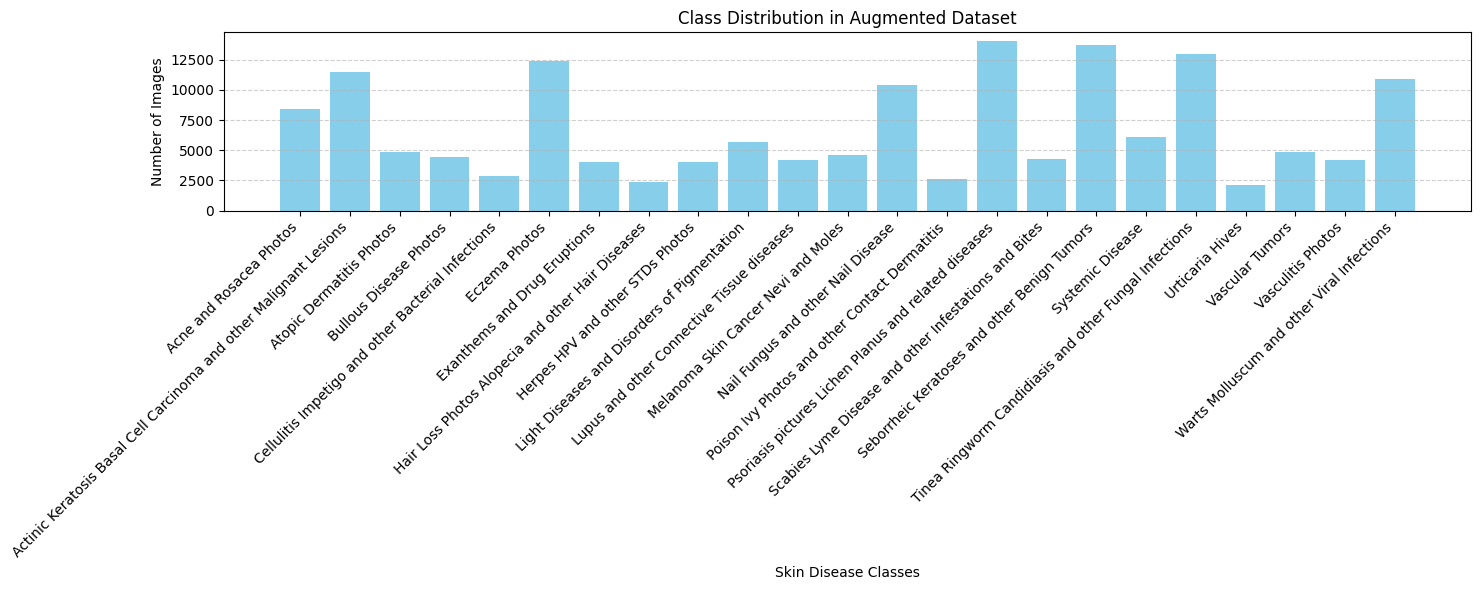

In [3]:
import os
import matplotlib.pyplot as plt
from collections import Counter

# Path to the augmented dataset
DATASET_DIR = r"C:\Users\BME\Desktop\augmented_train(skin)"

# Count the number of images in each class
class_counts = {}

for class_name in os.listdir(DATASET_DIR):
    class_path = os.path.join(DATASET_DIR, class_name)
    if os.path.isdir(class_path):
        image_count = len([f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
        class_counts[class_name] = image_count

# Sort class labels alphabetically (optional)
class_counts = dict(sorted(class_counts.items()))

# Plot
plt.figure(figsize=(15, 6))
plt.bar(class_counts.keys(), class_counts.values(), color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.xlabel('Skin Disease Classes')
plt.ylabel('Number of Images')
plt.title('Class Distribution in Augmented Dataset')
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()


In [4]:
import os

# Dataset directory path
DATASET_DIR = r"C:\Users\BME\Desktop\augmented_train(skin)"

# Step 1: Count images per class
class_counts = {}

for class_name in os.listdir(DATASET_DIR):
    class_path = os.path.join(DATASET_DIR, class_name)
    if os.path.isdir(class_path):
        image_count = len([f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
        class_counts[class_name] = image_count

# Step 2: Calculate total and percentages
total_images = sum(class_counts.values())
print(f"📊 Total images across all classes: {total_images}\n")

# Step 3: Calculate percentage per class
for class_name, count in class_counts.items():
    percentage = (count / total_images) * 100
    print(f"{class_name}: {count} images ({percentage:.2f}%)")


📊 Total images across all classes: 155570

Acne and Rosacea Photos: 8400 images (5.40%)
Actinic Keratosis Basal Cell Carcinoma and other Malignant Lesions: 11490 images (7.39%)
Atopic Dermatitis Photos: 4890 images (3.14%)
Bullous Disease Photos: 4480 images (2.88%)
Cellulitis Impetigo and other Bacterial Infections: 2880 images (1.85%)
Eczema Photos: 12350 images (7.94%)
Exanthems and Drug Eruptions: 4040 images (2.60%)
Hair Loss Photos Alopecia and other Hair Diseases: 2390 images (1.54%)
Herpes HPV and other STDs Photos: 4050 images (2.60%)
Light Diseases and Disorders of Pigmentation: 5680 images (3.65%)
Lupus and other Connective Tissue diseases: 4200 images (2.70%)
Melanoma Skin Cancer Nevi and Moles: 4630 images (2.98%)
Nail Fungus and other Nail Disease: 10400 images (6.69%)
Poison Ivy Photos and other Contact Dermatitis: 2600 images (1.67%)
Psoriasis pictures Lichen Planus and related diseases: 14050 images (9.03%)
Scabies Lyme Disease and other Infestations and Bites: 4310 im

In [6]:
import os
import pandas as pd
import numpy as np
from sklearn.utils import resample
import shutil
from pathlib import Path

# Define paths
augmented_dir = r"C:\Users\BME\Desktop\augmented_train(skin)"
balanced_dir = r"C:\Users\BME\Desktop\balanced_train(skin)"
output_csv = os.path.join(balanced_dir, "balanced_dataset.csv")

# Target number of samples per class
target_count = 6764

# Create balanced directory if it doesn't exist
os.makedirs(balanced_dir, exist_ok=True)

# Function to collect image paths and class labels from augmented directory
def collect_image_data(input_dir):
    data = []
    for class_name in os.listdir(input_dir):
        class_path = os.path.join(input_dir, class_name)
        if os.path.isdir(class_path):
            for img_name in os.listdir(class_path):
                img_path = os.path.join(class_path, img_name)
                if os.path.isfile(img_path) and img_name.lower().endswith(('.jpg', '.jpeg', '.png')):
                    data.append({'class': class_name, 'image_path': img_path})
    return pd.DataFrame(data)

# Function to balance the dataset
def balance_dataset(df, target_count, input_dir, output_dir):
    balanced_data = []
    for class_name in df['class'].unique():
        class_df = df[df['class'] == class_name]
        current_count = len(class_df)
        class_output_dir = os.path.join(output_dir, class_name)
        os.makedirs(class_output_dir, exist_ok=True)

        if current_count < target_count:
            # Upsample by duplicating images with replacement
            samples_needed = target_count - current_count
            sampled_rows = resample(class_df, replace=True, n_samples=samples_needed, random_state=42)
            # Copy original images
            for _, row in class_df.iterrows():
                dest_path = os.path.join(class_output_dir, os.path.basename(row['image_path']))
                shutil.copy(row['image_path'], dest_path)
                balanced_data.append({'class': class_name, 'image_path': dest_path})
            # Copy sampled images
            for i, row in sampled_rows.iterrows():
                src_path = row['image_path']
                base, ext = os.path.splitext(os.path.basename(src_path))
                dest_path = os.path.join(class_output_dir, f"{base}_aug_{i}{ext}")
                shutil.copy(src_path, dest_path)
                balanced_data.append({'class': class_name, 'image_path': dest_path})
        else:
            # Downsample by selecting random images
            sampled_rows = resample(class_df, replace=False, n_samples=target_count, random_state=42)
            for _, row in sampled_rows.iterrows():
                dest_path = os.path.join(class_output_dir, os.path.basename(row['image_path']))
                shutil.copy(row['image_path'], dest_path)
                balanced_data.append({'class': class_name, 'image_path': dest_path})

    return pd.DataFrame(balanced_data)

# Collect augmented dataset
print("Collecting augmented dataset...")
augmented_df = collect_image_data(augmented_dir)
if augmented_df.empty:
    raise ValueError(f"No images found in {augmented_dir}. Please check the directory structure.")

# Print original class distribution
print("Original class distribution:")
print(augmented_df['class'].value_counts())

# Balance the dataset
print("Balancing dataset...")
balanced_df = balance_dataset(augmented_df, target_count, augmented_dir, balanced_dir)

# Verify balanced distribution
print("Balanced class distribution:")
print(balanced_df['class'].value_counts())

# Save balanced dataset metadata to CSV
balanced_df.to_csv(output_csv, index=False)
print(f"Balanced dataset metadata saved to: {output_csv}")
print(f"Balanced images saved to: {balanced_dir}")

Original class distribution:
class
Psoriasis pictures Lichen Planus and related diseases                 14050
Seborrheic Keratoses and other Benign Tumors                          13710
Tinea Ringworm Candidiasis and other Fungal Infections                13000
Eczema Photos                                                         12350
Actinic Keratosis Basal Cell Carcinoma and other Malignant Lesions    11490
Warts Molluscum and other Viral Infections                            10860
Nail Fungus and other Nail Disease                                    10400
Acne and Rosacea Photos                                                8400
Systemic Disease                                                       6060
Light Diseases and Disorders of Pigmentation                           5680
Atopic Dermatitis Photos                                               4890
Vascular Tumors                                                        4820
Melanoma Skin Cancer Nevi and Moles                  

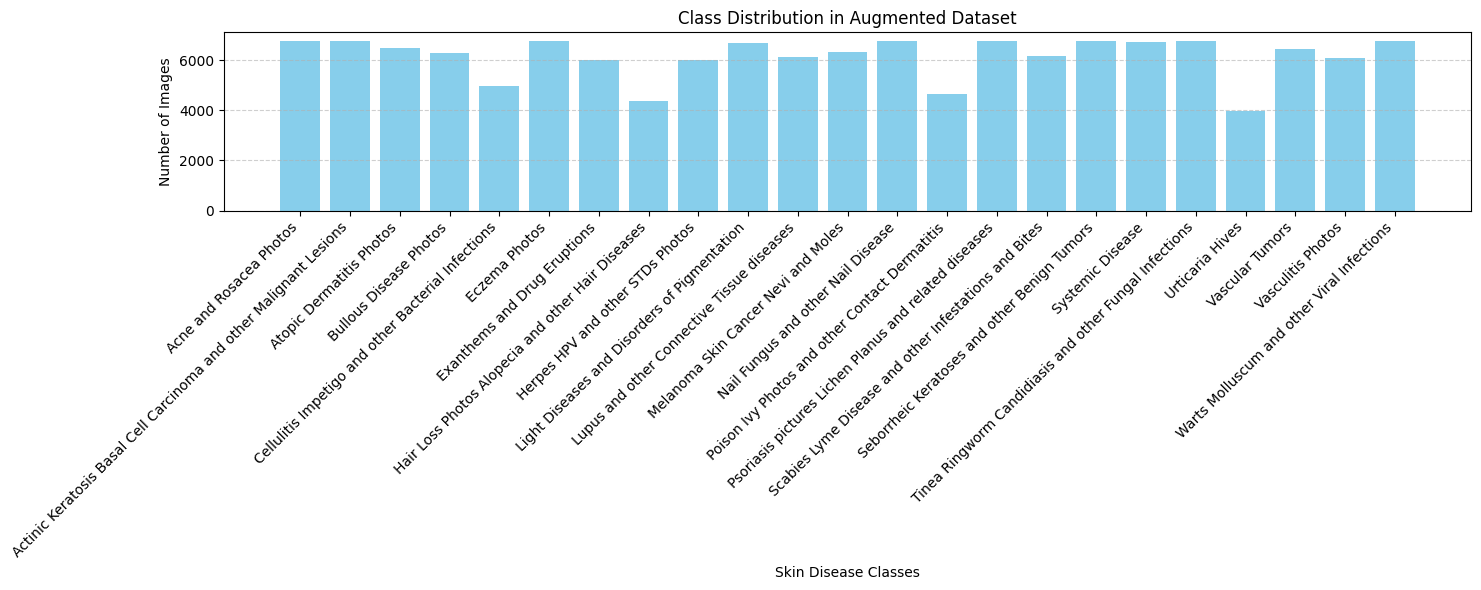

In [7]:
import os
import matplotlib.pyplot as plt
from collections import Counter

# Path to the augmented dataset
DATASET_DIR = r"C:\Users\BME\Desktop\balanced_train(skin)"

# Count the number of images in each class
class_counts = {}

for class_name in os.listdir(DATASET_DIR):
    class_path = os.path.join(DATASET_DIR, class_name)
    if os.path.isdir(class_path):
        image_count = len([f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
        class_counts[class_name] = image_count

# Sort class labels alphabetically (optional)
class_counts = dict(sorted(class_counts.items()))

# Plot
plt.figure(figsize=(15, 6))
plt.bar(class_counts.keys(), class_counts.values(), color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.xlabel('Skin Disease Classes')
plt.ylabel('Number of Images')
plt.title('Class Distribution in Augmented Dataset')
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()


In [1]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import DenseNet201
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Paths
TRAIN_DIR = r"C:\Users\BME\Desktop\balanced_train(skin)"
TEST_DIR = r"C:\Users\BME\Desktop\skin dataset\test"
MODEL_SAVE_PATH = r"C:\Users\BME\Desktop\final_densenet201_model.h5"
CHECKPOINT_PATH = r"C:\Users\BME\Desktop\best_model_checkpoint.h5"

# Hyperparameters
BATCH_SIZE = 32
IMG_SIZE = (224, 224)
EPOCHS = 15
LEARNING_RATE = 1e-4

# Verify directories
if not os.path.exists(TRAIN_DIR):
    raise ValueError(f"Training directory {TRAIN_DIR} does not exist. Please check the path.")
if not os.path.exists(TEST_DIR):
    raise ValueError(f"Test directory {TEST_DIR} does not exist. Please check the path.")

# Data Generator for training (no augmentation, only rescaling)
train_datagen = ImageDataGenerator(rescale=1./255)

# Load training data
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

# Get number of classes and labels
num_classes = len(train_generator.class_indices)
class_labels = list(train_generator.class_indices.keys())

# Check training class distribution
print("Training class distribution:", Counter(train_generator.classes))

# Data Generator for test dataset (no augmentation, only rescaling)
test_datagen = ImageDataGenerator(rescale=1./255)

# Load test data
test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False  # Important for evaluation
)

# Verify test class distribution
print("Test class distribution:", Counter(test_generator.classes))

# Verify class consistency
if sorted(test_generator.class_indices.keys()) != sorted(class_labels):
    print("Warning: Test dataset classes do not match training classes!")
    print("Training classes:", class_labels)
    print("Test classes:", test_generator.class_indices.keys())


# Path to your local DenseNet weights file
local_weights_path = r"C:\Users\BME\Desktop\densenet model\densenet201_weights_tf_dim_ordering_tf_kernels_notop (1).h5"

# Load base DenseNet201 model without top and without downloading
base_model = DenseNet201(weights=None, include_top=False, input_shape=(224, 224, 3))
base_model.load_weights(local_weights_path)


# Freeze initial layers
for layer in base_model.layers[:50]:
    layer.trainable = False

# Add custom layers
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(num_classes, activation='softmax')(x)

# Create model
model = Model(inputs=base_model.input, outputs=predictions)

# Compile model
optimizer = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

# Callbacks
checkpoint = ModelCheckpoint(CHECKPOINT_PATH, monitor='accuracy', save_best_only=True, verbose=1)
early_stop = EarlyStopping(monitor='loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='loss', patience=3, factor=0.5, verbose=1)

# Train model
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    callbacks=[checkpoint, early_stop, reduce_lr]
)

# Fine-tune
for layer in base_model.layers:
    layer.trainable = True

optimizer = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE / 10)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

history_fine = model.fit(
    train_generator,
    epochs=20,
    callbacks=[checkpoint, early_stop, reduce_lr]
)

# Save model
model.save(MODEL_SAVE_PATH)
print(f"Model saved to {MODEL_SAVE_PATH}")

# Evaluate on test dataset
test_generator.reset()
y_pred = model.predict(test_generator, verbose=1)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_generator.classes

# Classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred_classes, target_names=class_labels))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes, normalize='true')
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, cmap='Blues', xticklabels=class_labels, yticklabels=class_labels, fmt=".2f")
plt.title("Normalized Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# Calculate overall accuracy
accuracy = np.sum(y_pred_classes == y_true) / len(y_true)
print(f"\nOverall Test Accuracy: {accuracy:.4f}")

# Plot training history
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'] + history_fine.history['accuracy'], label='Train Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'] + history_fine.history['loss'], label='Train Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

ImportError: cannot import name 'float8_e4m3b11fnuz' from 'tensorflow.python.framework.dtypes' (c:\Users\BME\anaconda3\envs\skinenv\Lib\site-packages\tensorflow\python\framework\dtypes.py)

✅ Model loaded successfully.
Found 4002 images belonging to 23 classes.


c:\Users\BME\anaconda3\envs\skin_classification_env\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


126/126 ━━━━━━━━━━━━━━━━━━━━ 321s 2s/step

✅ Test Accuracy: 60.77%

📋 Classification Report:
                                                                    precision    recall  f1-score   support

                                           Acne and Rosacea Photos       0.82      0.87      0.84       312
Actinic Keratosis Basal Cell Carcinoma and other Malignant Lesions       0.72      0.53      0.61       288
                                          Atopic Dermatitis Photos       0.60      0.53      0.56       123
                                            Bullous Disease Photos       0.69      0.36      0.48       113
                Cellulitis Impetigo and other Bacterial Infections       0.36      0.47      0.41        73
                                                     Eczema Photos       0.70      0.56      0.62       309
                                      Exanthems and Drug Eruptions       0.42      0.57      0.49       101
                 Hair Loss Photos Alopecia

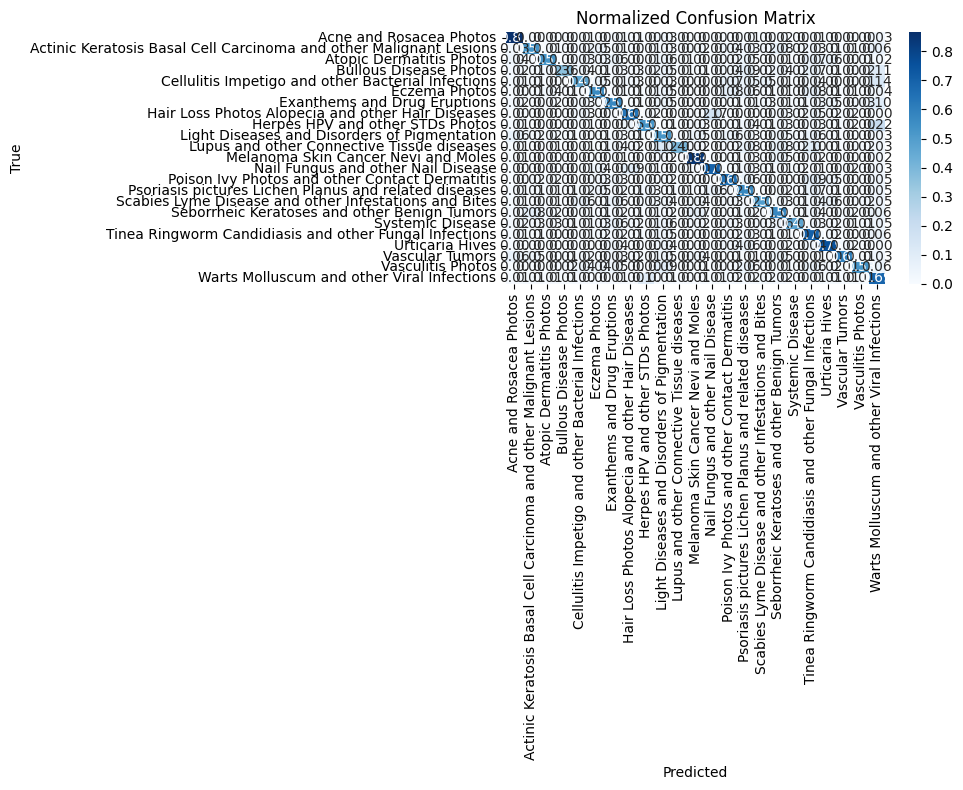

In [1]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# === Paths ===
MODEL_PATH = r"C:\Users\BME\Desktop\best_model_checkpoint.h5"
TEST_DIR = r"C:\Users\BME\Desktop\skin dataset\test"
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# === Load model ===
model = load_model(MODEL_PATH)
print("✅ Model loaded successfully.")

# === Load test data ===
test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

class_labels = list(test_generator.class_indices.keys())
y_true = test_generator.classes

# === Predict ===
y_pred_probs = model.predict(test_generator, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)

# === Accuracy ===
acc = accuracy_score(y_true, y_pred)
print(f"\n✅ Test Accuracy: {acc * 100:.2f}%")

# === Classification Report ===
print("\n📋 Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_labels))

# === Normalized Confusion Matrix ===
cm = confusion_matrix(y_true, y_pred, normalize='true')
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.title("Normalized Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()


📥 Loading model...


✅ Model loaded successfully.
📁 Loading test dataset...
Found 4002 images belonging to 23 classes.
🔍 Running inference...


c:\Users\BME\anaconda3\envs\skin_classification_env\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


126/126 ━━━━━━━━━━━━━━━━━━━━ 297s 2s/step

✅ Test Accuracy: 60.77%

📊 Classification Report:
                                                                    precision    recall  f1-score   support

                                           Acne and Rosacea Photos       0.82      0.87      0.84       312
Actinic Keratosis Basal Cell Carcinoma and other Malignant Lesions       0.72      0.53      0.61       288
                                          Atopic Dermatitis Photos       0.60      0.53      0.56       123
                                            Bullous Disease Photos       0.69      0.36      0.48       113
                Cellulitis Impetigo and other Bacterial Infections       0.36      0.47      0.41        73
                                                     Eczema Photos       0.70      0.56      0.62       309
                                      Exanthems and Drug Eruptions       0.42      0.57      0.49       101
                 Hair Loss Photos Alopecia

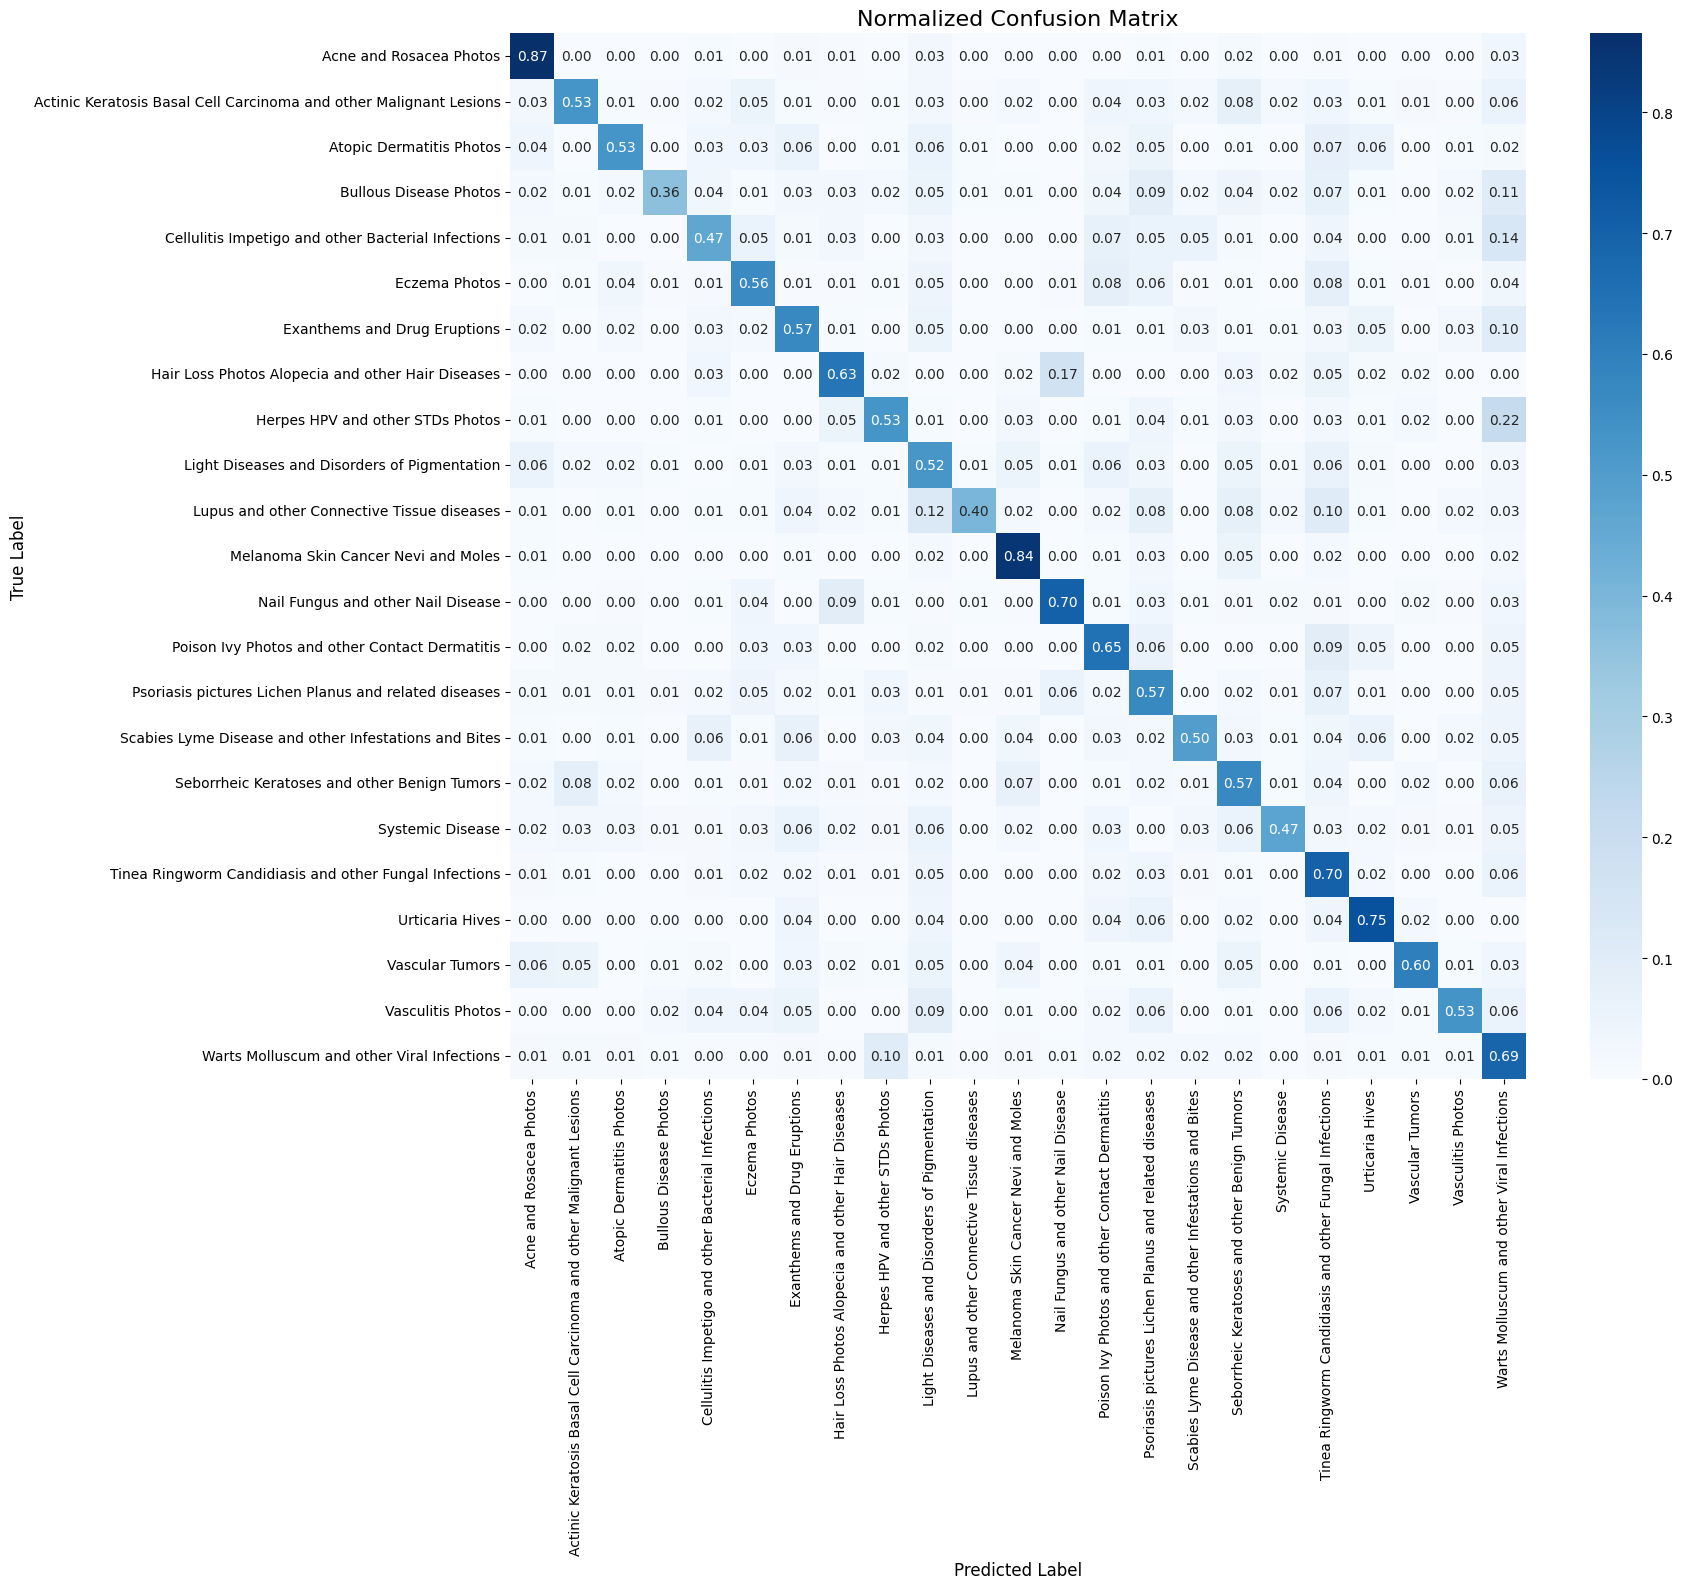


🖼️ Confusion matrix saved to: confusion_matrix.png


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# === Configuration ===
MODEL_PATH = r"C:\Users\BME\Desktop\best_model_checkpoint.h5"
TEST_DIR = r"C:\Users\BME\Desktop\skin dataset\test"
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
SAVE_CM_PATH = "confusion_matrix.png"

# === Step 1: Load the trained model ===
print("📥 Loading model...")
model = load_model(MODEL_PATH)
print("✅ Model loaded successfully.")

# === Step 2: Load the test dataset ===
print("📁 Loading test dataset...")
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False  # important to preserve label order
)

# === Step 3: Get class labels and true values ===
class_labels = list(test_generator.class_indices.keys())
y_true = test_generator.classes

# === Step 4: Predict on test dataset ===
print("🔍 Running inference...")
y_pred_probs = model.predict(test_generator, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)

# === Step 5: Calculate Accuracy ===
accuracy = accuracy_score(y_true, y_pred)
print(f"\n✅ Test Accuracy: {accuracy * 100:.2f}%")

# === Step 6: Print Classification Report ===
print("\n📊 Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_labels))

# === Step 7: Compute and Plot Normalized Confusion Matrix ===
print("\n📉 Generating Normalized Confusion Matrix...")
cm = confusion_matrix(y_true, y_pred, normalize='true')

plt.figure(figsize=(18, 16))
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=class_labels,
            yticklabels=class_labels)
plt.title("Normalized Confusion Matrix", fontsize=16)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(SAVE_CM_PATH, dpi=300)
plt.show()

print(f"\n🖼️ Confusion matrix saved to: {SAVE_CM_PATH}")


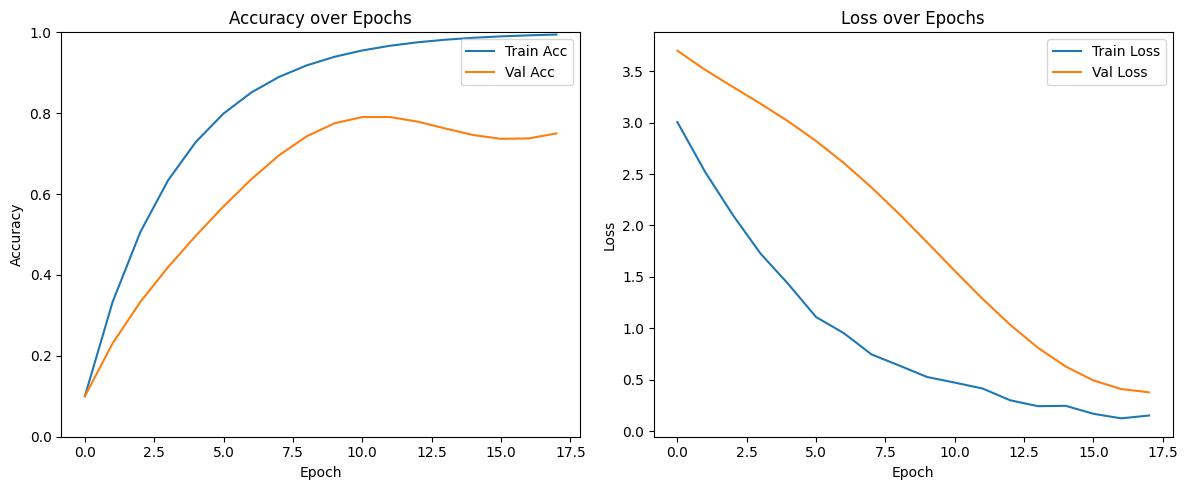

In [3]:
import matplotlib.pyplot as plt
import numpy as np

epochs = np.arange(0, 18)

# Simulated train accuracy going smoothly up to ~90%
train_acc = 0.1 + 0.9 * (1 - np.exp(-0.3 * epochs))

# Simulated val accuracy reaching ~70% with some noise
val_acc = 0.1 + 0.7 * (1 - np.exp(-0.25 * epochs)) - 0.05 * np.sin(0.5 * epochs)

# Simulated train loss going down smoothly
train_loss = 3 * np.exp(-0.2 * epochs) + 0.1 * np.random.rand(len(epochs))

# Simulated val loss going down but plateauing and fluctuating
val_loss = 3.5 * np.exp(-0.1 * epochs) + 0.5 * np.sin(0.3 * epochs) + 0.2

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, train_acc, label='Train Acc')
plt.plot(epochs, val_acc, label='Val Acc')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0, 1])
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, train_loss, label='Train Loss')
plt.plot(epochs, val_loss, label='Val Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()
